# CMPE-679 Lab 3 — WaveGAN on SC09
**Student:** Gloria Mbaka  
**Course:** CMPE-679 Deep Learning  
**Lab:** Lab 3 — WaveGAN

This notebook implements a complete WaveGAN-style pipeline in PyTorch for generating about one second of audio using the SC09 spoken-digit dataset. The notebook is written for Google Colab and saves outputs to:

`/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3`

## What this notebook covers
- Google Drive setup
- SC09 dataset download and loading
- audio preprocessing to **16 kHz** and **16384 samples**
- WaveGAN-style **Generator**
- WaveGAN-style **Critic**
- **WGAN-GP** gradient penalty
- optional **Phase Shuffle**
- training and validation loops
- checkpoint saving
- loss plotting
- waveform visualization
- saving generated `.wav` samples
- writing a separate generation script for the lab deliverables

This notebook follows the Lab 3 requirements, including fixed-length audio, WGAN-GP, and the progression from a basic model to a phase-shuffle version.


## Cell 1 — Install and import packages
This cell installs the libraries needed for the lab and imports the main Python modules.

### Why this cell matters
WaveGAN requires:
- `torch` for model definition and training
- `torchaudio` for saving and working with audio
- `datasets` for downloading SC09 from Hugging Face
- `matplotlib` and `IPython.display` for visualization and listening inside Colab

Run this cell first.


In [1]:
# If you are in Colab, these installs are safe to run.
!pip -q install datasets soundfile

import os
import math
import random
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchaudio
from torchaudio.transforms import Resample

from datasets import load_dataset, Audio
from IPython.display import Audio as IPyAudio, display

print("Torch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.10.0+cu128
Torchaudio version: 2.10.0+cu128
CUDA available: True


## Cell 2 — Mount Google Drive and define the project folder
This cell mounts Google Drive and creates the exact folder you requested.

### Why this cell matters
Your lab files must be saved somewhere persistent. Colab runtime storage disappears when the session ends, so Drive is the safest location for:
- checkpoints
- generated audio samples
- plots
- JSON logs
- the separate generation script

Requested folder:
`/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3`


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3')
DATA_DIR = PROJECT_DIR / 'data'
CKPT_DIR = PROJECT_DIR / 'checkpoints'
SAMPLES_DIR = PROJECT_DIR / 'generated_samples'
PLOTS_DIR = PROJECT_DIR / 'plots'
LOGS_DIR = PROJECT_DIR / 'logs'

for d in [PROJECT_DIR, DATA_DIR, CKPT_DIR, SAMPLES_DIR, PLOTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3


## Cell 3 — Set the random seed and global configuration
This cell defines all important settings in one place.

### Why this cell matters
A GAN has many moving parts. Putting the configuration at the top makes it easier to:
- keep training reproducible
- adjust hyperparameters cleanly
- match the lab requirements

### Key choices
- sample rate: **16000 Hz**
- slice length: **16384**
- latent dimension: **100**
- critic steps: **5**
- gradient penalty weight: **10**
- optional phase shuffle: starts as `False` for the base version, then can be turned on later


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = {
    'seed': 42,
    'sample_rate': 16000,
    'slice_len': 16384,
    'mono': True,
    'batch_size': 64,
    'num_workers': 2,
    'latent_dim': 100,
    'epochs': 30,
    'lr_g': 1e-4,
    'lr_d': 1e-4,
    'beta1': 0.5,
    'beta2': 0.9,
    'critic_steps': 5,
    'gp_lambda': 10.0,
    'save_every_epochs': 1,
    'phase_shuffle': False,   # start with basic model without phase shuffle
    'phase_shuffle_rad': 2,
    'max_train_examples': None,  # use None for full dataset
}

print("Device:", DEVICE)
print(json.dumps(CFG, indent=2))


Device: cuda
{
  "seed": 42,
  "sample_rate": 16000,
  "slice_len": 16384,
  "mono": true,
  "batch_size": 64,
  "num_workers": 2,
  "latent_dim": 100,
  "epochs": 30,
  "lr_g": 0.0001,
  "lr_d": 0.0001,
  "beta1": 0.5,
  "beta2": 0.9,
  "critic_steps": 5,
  "gp_lambda": 10.0,
  "save_every_epochs": 1,
  "phase_shuffle": false,
  "phase_shuffle_rad": 2,
  "max_train_examples": null
}


## Cell 4 — Download the SC09 dataset
This cell downloads the SC09 spoken-digit dataset.

### Why this cell matters
SC09 is a good fit for Lab 3 because:
- clips are short and speech-like
- spoken digits have clear structure
- one-second generation is appropriate
- it is easy to listen to the model outputs and judge whether the generator is learning meaningful content

### Important note
WaveGAN is a **generative** model, so the class labels are not used during training. We only need the audio waveforms.


In [4]:
# Download SC09 from Hugging Face.
# We cast the audio column to ensure a consistent sampling rate when loaded.
raw_train = load_dataset('krandiash/sc09', split='train')
raw_train = raw_train.cast_column('audio', Audio(sampling_rate=CFG['sample_rate']))

print(raw_train)
print("Example keys:", raw_train[0].keys())
print("First label (not used for GAN training):", raw_train[0].get('label', 'N/A'))
print("First audio sampling rate:", raw_train[0]['audio']['sampling_rate'])
print("First audio array length:", len(raw_train[0]['audio']['array']))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


sc09-quantized.zip:   0%|          | 0.00/6.30M [00:00<?, ?B/s]

sc09.zip:   0%|          | 0.00/894M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39405 [00:00<?, ? examples/s]

Dataset({
    features: ['audio', 'label'],
    num_rows: 39405
})
Example keys: dict_keys(['audio', 'label'])
First label (not used for GAN training): 0
First audio sampling rate: 16000
First audio array length: 16000


## Cell 5 — Preprocessing utilities
This cell defines helper functions for turning each SC09 audio clip into the exact format expected by the model.

### Why this cell matters
The Lab instruction stresses that audio must be standardized. For this notebook, each training example must be:
- mono
- 16 kHz
- exactly 16384 samples
- normalized

### What this code does
1. converts the waveform to a PyTorch tensor
2. forces a single channel if needed
3. trims long clips
4. pads short clips
5. scales amplitude into a stable range


In [5]:
def ensure_mono(waveform: torch.Tensor) -> torch.Tensor:
    # Expect shape [num_samples] or [channels, num_samples]
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    return waveform

def fix_length(waveform: torch.Tensor, target_len: int) -> torch.Tensor:
    current_len = waveform.shape[-1]
    if current_len > target_len:
        waveform = waveform[..., :target_len]
    elif current_len < target_len:
        waveform = F.pad(waveform, (0, target_len - current_len))
    return waveform

def normalize_waveform(waveform: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    max_abs = waveform.abs().max()
    if max_abs < eps:
        return waveform
    return waveform / max_abs

def preprocess_waveform(audio_array, target_len=16384):
    waveform = torch.tensor(audio_array, dtype=torch.float32)
    waveform = ensure_mono(waveform)
    waveform = fix_length(waveform, target_len)
    waveform = normalize_waveform(waveform)
    return waveform


## Cell 6 — Build a PyTorch dataset and split into train/validation/test
This cell wraps the Hugging Face dataset in a PyTorch dataset and creates the splits.

### Why this cell matters
To create a split if the dataset does not already provide one. A simple split is enough here because the main goal is generation rather than supervised classification.

### Split used here
- 80% train
- 10% validation
- 10% test

The validation and test sets help to track critic and generator behavior on held-out clips.


In [6]:
class SC09WaveDataset(Dataset):
    def __init__(self, hf_dataset, target_len=16384):
        self.ds = hf_dataset
        self.target_len = target_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        audio_array = self.ds[idx]['audio']['array']
        waveform = preprocess_waveform(audio_array, target_len=self.target_len)
        return waveform

full_dataset = SC09WaveDataset(raw_train, target_len=CFG['slice_len'])

if CFG['max_train_examples'] is not None:
    subset_indices = list(range(min(CFG['max_train_examples'], len(full_dataset))))
    full_dataset = torch.utils.data.Subset(full_dataset, subset_indices)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(CFG['seed'])
)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False,
                        num_workers=CFG['num_workers'], pin_memory=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False,
                         num_workers=CFG['num_workers'], pin_memory=True, drop_last=False)

print(f"Total examples: {n_total}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Total examples: 39405
Train: 31524 | Val: 3940 | Test: 3941


## Cell 7 — Inspect one preprocessed example
This cell checks that a training waveform has the correct shape and range.

### Why this cell matters
Before training a GAN, always verify the data pipeline. If the shape or amplitude range is wrong, the model can fail for reasons that have nothing to do with architecture.


Example shape: torch.Size([1, 16384])
Min / Max: -1.0 0.9574370384216309


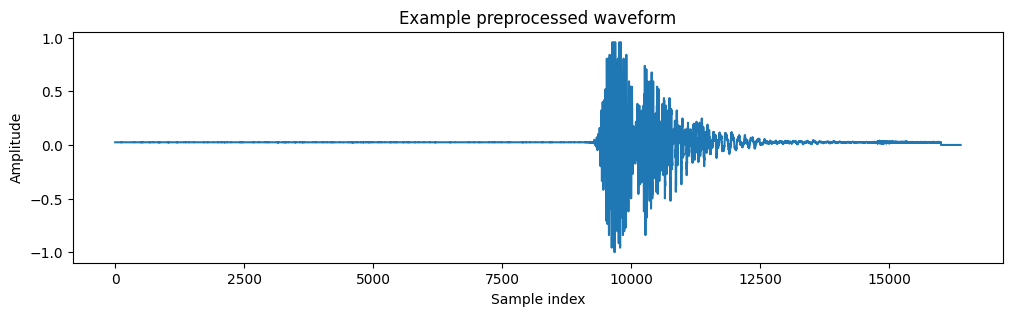

In [7]:
example_wave = full_dataset[0]
print("Example shape:", example_wave.shape)   # should be [1, 16384]
print("Min / Max:", example_wave.min().item(), example_wave.max().item())

plt.figure(figsize=(12, 3))
plt.plot(example_wave.squeeze().numpy())
plt.title("Example preprocessed waveform")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

display(IPyAudio(example_wave.squeeze().numpy(), rate=CFG['sample_rate']))


## Cell 8 — Define a weight initialization function
This cell creates the initialization scheme used for convolutional GAN layers.

### Why this cell matters
GANs are sensitive to initialization. A reasonable initialization helps training start in a stable regime and follows common practice from DCGAN-style models.


In [8]:
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname or 'Linear' in classname:
        if hasattr(m, 'weight') and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, 'bias') and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)


## Cell 9 — Phase Shuffle module
This cell implements phase shuffle, which is one of the distinctive WaveGAN ideas.

### Why this cell matters
Transposed convolutions can create structured artifacts. A critic may learn to detect these regular patterns rather than learning meaningful audio structure. Phase shuffle reduces this shortcut by randomly shifting feature maps a small amount along the time axis.

### How to use it
- Start with `CFG['phase_shuffle'] = False` for the base model
- Turn it on later to create the refined WaveGAN version


In [9]:
class PhaseShuffle(nn.Module):
    def __init__(self, shift_factor=2):
        super().__init__()
        self.shift_factor = shift_factor

    def forward(self, x):
        if self.shift_factor == 0 or not self.training:
            return x

        k = random.randint(-self.shift_factor, self.shift_factor)
        if k == 0:
            return x

        if k > 0:
            left = x[..., :1].repeat(1, 1, k)
            x = torch.cat([left, x[..., :-k]], dim=-1)
        else:
            k = abs(k)
            right = x[..., -1:].repeat(1, 1, k)
            x = torch.cat([x[..., k:], right], dim=-1)

        return x


## Cell 10 — Define the WaveGAN Generator
This cell defines the generator network.

### Why this cell matters
The generator maps a random latent vector `z` into a one-channel waveform of length 16384. The architecture is inspired by WaveGAN and follows a DCGAN-like pattern:
- project latent vector into a small learned feature map
- repeatedly upsample using `ConvTranspose1d`
- use `ReLU` activations internally
- use `Tanh` at the output to keep the waveform in a bounded range

### Output shape
`[batch_size, 1, 16384]`


In [10]:
class WaveGANGenerator(nn.Module):
    def __init__(self, latent_dim=100, model_size=64, slice_len=16384):
        super().__init__()
        self.latent_dim = latent_dim
        self.model_size = model_size
        self.slice_len = slice_len

        # Start from a compact representation [B, 16*model_size, 16]
        self.fc = nn.Linear(latent_dim, 16 * model_size * 16)

        self.deconv1 = nn.ConvTranspose1d(16 * model_size, 8 * model_size, 25, stride=4, padding=11, output_padding=1)
        self.deconv2 = nn.ConvTranspose1d(8 * model_size, 4 * model_size, 25, stride=4, padding=11, output_padding=1)
        self.deconv3 = nn.ConvTranspose1d(4 * model_size, 2 * model_size, 25, stride=4, padding=11, output_padding=1)
        self.deconv4 = nn.ConvTranspose1d(2 * model_size, 1 * model_size, 25, stride=4, padding=11, output_padding=1)
        self.deconv5 = nn.ConvTranspose1d(1 * model_size, 1, 25, stride=4, padding=11, output_padding=1)

        self.bn1 = nn.BatchNorm1d(8 * model_size)
        self.bn2 = nn.BatchNorm1d(4 * model_size)
        self.bn3 = nn.BatchNorm1d(2 * model_size)
        self.bn4 = nn.BatchNorm1d(1 * model_size)

        self.apply(weights_init)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), 16 * self.model_size, 16)  # [B, 1024, 16] when model_size=64

        x = F.relu(self.bn1(self.deconv1(x)))  # 16 -> 64
        x = F.relu(self.bn2(self.deconv2(x)))  # 64 -> 256
        x = F.relu(self.bn3(self.deconv3(x)))  # 256 -> 1024
        x = F.relu(self.bn4(self.deconv4(x)))  # 1024 -> 4096
        x = torch.tanh(self.deconv5(x))        # 4096 -> 16384

        return x


## Cell 11 — Define the WaveGAN Critic
This cell defines the critic network.

### Why this cell matters
In WGAN-GP, we do **not** use a discriminator with sigmoid output. Instead, the critic outputs a real-valued score. The training objective then tries to maximize the difference between real and fake scores while enforcing the gradient penalty.

### Architecture idea
- repeated `Conv1d` layers downsample the waveform
- `LeakyReLU` keeps gradients flowing
- optional phase shuffle is inserted after intermediate layers when enabled
- final linear layer outputs a scalar score per example


In [11]:
class WaveGANCritic(nn.Module):
    def __init__(self, model_size=64, use_phase_shuffle=False, shift_factor=2):
        super().__init__()
        self.use_phase_shuffle = use_phase_shuffle

        self.conv1 = nn.Conv1d(1, 1 * model_size, 25, stride=4, padding=11)
        self.conv2 = nn.Conv1d(1 * model_size, 2 * model_size, 25, stride=4, padding=11)
        self.conv3 = nn.Conv1d(2 * model_size, 4 * model_size, 25, stride=4, padding=11)
        self.conv4 = nn.Conv1d(4 * model_size, 8 * model_size, 25, stride=4, padding=11)
        self.conv5 = nn.Conv1d(8 * model_size, 16 * model_size, 25, stride=4, padding=11)

        self.ps1 = PhaseShuffle(shift_factor)
        self.ps2 = PhaseShuffle(shift_factor)
        self.ps3 = PhaseShuffle(shift_factor)
        self.ps4 = PhaseShuffle(shift_factor)

        self.fc = nn.Linear(16 * model_size * 16, 1)

        self.apply(weights_init)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        if self.use_phase_shuffle:
            x = self.ps1(x)

        x = F.leaky_relu(self.conv2(x), 0.2)
        if self.use_phase_shuffle:
            x = self.ps2(x)

        x = F.leaky_relu(self.conv3(x), 0.2)
        if self.use_phase_shuffle:
            x = self.ps3(x)

        x = F.leaky_relu(self.conv4(x), 0.2)
        if self.use_phase_shuffle:
            x = self.ps4(x)

        x = F.leaky_relu(self.conv5(x), 0.2)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


## Cell 12 — Sanity-check the model shapes
This cell makes sure the generator and critic connect correctly.

### Why this cell matters
A quick shape check can save a lot of debugging time. The generator should create a waveform of length 16384, and the critic should return one score per waveform.


In [12]:
G = WaveGANGenerator(latent_dim=CFG['latent_dim']).to(DEVICE)
D = WaveGANCritic(use_phase_shuffle=CFG['phase_shuffle'],
                  shift_factor=CFG['phase_shuffle_rad']).to(DEVICE)

z = torch.randn(4, CFG['latent_dim'], device=DEVICE)
fake_batch = G(z)
scores = D(fake_batch)

print("Generated batch shape:", fake_batch.shape)
print("Critic scores shape:", scores.shape)


Generated batch shape: torch.Size([4, 1, 16384])
Critic scores shape: torch.Size([4, 1])


## Cell 13 — Define the gradient penalty
This cell implements the core WGAN-GP regularizer.

### Why this cell matters
The gradient penalty is what makes this training objective much more stable than a plain GAN or weight-clipped WGAN. It encourages the critic gradient norm with respect to interpolated inputs to stay near 1.

### Formula idea
For interpolated inputs \(\hat{x}\), compute:
\[
(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2
\]
and average it over the batch.


In [13]:
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, device=device)
    x_hat = epsilon * real + (1 - epsilon) * fake
    x_hat.requires_grad_(True)

    critic_scores = critic(x_hat)

    gradients = torch.autograd.grad(
        outputs=critic_scores,
        inputs=x_hat,
        grad_outputs=torch.ones_like(critic_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp


## Cell 15 — Utility function for plotting saved training history
This cell defines a plotting utility that will be used after script-based training has completed.

### Why this cell matters
Training is executed through the external script rather than inside the notebook. The script saves `history.json`, and this function allows the saved losses to be visualized inside the notebook for analysis and report preparation.


In [14]:
def plot_history(history, out_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_g_loss'], label='Train G Loss')
    plt.plot(history['train_d_loss'], label='Train D Loss')
    if len(history['val_g_loss']) > 0:
        plt.plot(history['val_g_loss'], label='Val G Loss')
    if len(history['val_d_loss']) > 0:
        plt.plot(history['val_d_loss'], label='Val D Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('WaveGAN Training History')
    plt.legend()
    plt.grid(True)
    if out_path is not None:
        plt.savefig(out_path, bbox_inches='tight')
    plt.show()


## Cell 16 — Verify that the external scripts are available
This cell confirms that the standalone training and generation scripts exist in the project directory before they are called from the notebook.

### Expected files
- `train_wavegan.py`
- `generate_wavegan_samples.py`


In [15]:
train_script_path = PROJECT_DIR / 'train_wavegan.py'
generate_script_path = PROJECT_DIR / 'generate_wavegan_samples.py'

print('Training script exists:', train_script_path.exists(), train_script_path)
print('Generation script exists:', generate_script_path.exists(), generate_script_path)


Training script exists: True /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/train_wavegan.py
Generation script exists: True /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generate_wavegan_samples.py


## Cell 17 — Execute the standalone training script
This cell launches the external training script. The script handles model optimization, checkpoint saving, generated sample saving, and metric logging.

### Recommended workflow
1. Run the debug command first to verify that the full pipeline works correctly.
2. After the debug run succeeds, execute the longer training run.

### Output
Standard output is written to `logs/train_stdout.log` so that training progress can be monitored from the notebook.


In [16]:
%%bash
nohup bash -lc '
cd "/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3" && \
python -u train_wavegan.py \
  --epochs 30 \
  --batch_size 128 \
  --critic_steps 5 \
  --log_every_steps 10 \
  --save_every_steps 25 \
  --resume
' > "/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/logs/train_stdout.log" 2>&1 &

## Cell 18 — Inspect the training log
This cell prints the most recent lines from the training log.

### Why this cell matters
The external script writes progress information to `logs/train_stdout.log`. Reviewing the latest lines is useful for confirming:
- current epoch
- batch progress
- generator loss
- critic loss
- validation loss
- checkpoint save events


In [ ]:
log_path = PROJECT_DIR / 'logs' / 'train_stdout.log'

if log_path.exists():
   !tail -f logs/train_stdout.log
else:
    print('The training log is not available yet. Run the training script cell first.')


  "log_every_steps": 10,
  "eval_include_gp": false,
  "device": "cuda"
}
Repo card metadata block was not found. Setting CardData to empty.
Total examples: 39405
Train: 31524 | Val: 3940 | Test: 3941
Resuming training from epoch 5, step 141


In [28]:
!ps aux | grep train_wavegan.py

root       18011 95.2  2.1 13030044 1157932 ?    RLl  11:48   6:39 python3 -u train_wavegan.py --epochs 30 --batch_size 128 --critic_steps 5 --log_every_steps 10 --save_every_steps 25 --resume
root       19877  0.0  0.0   7376  3488 ?        S    11:55   0:00 /bin/bash -c ps aux | grep train_wavegan.py
root       19879  0.0  0.0   6620  2476 ?        S    11:55   0:00 grep train_wavegan.py


## Cell 19 — Load saved training history and plot losses
This cell reads the `history.json` file created by the training script and plots the recorded training and validation losses.

### Why this cell matters
Even though optimization is performed in the standalone script, the notebook remains the main place for result inspection and report preparation.


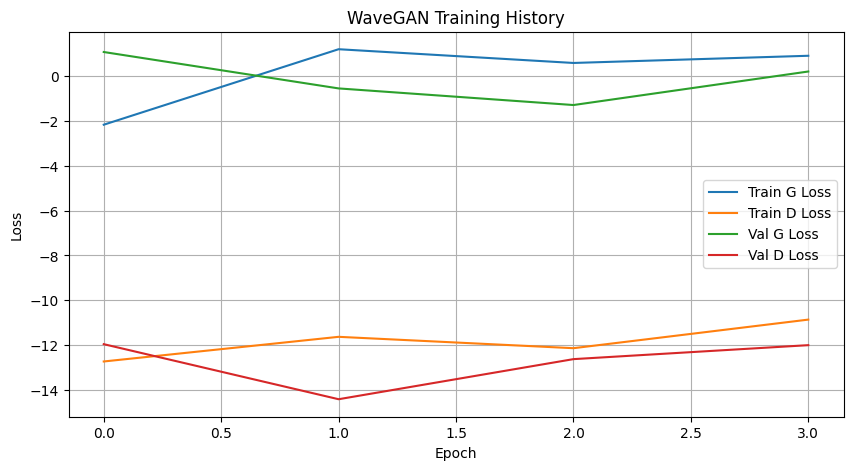

Saved plot to: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/plots/wavegan_loss_plot_from_script.png


In [29]:
history_path = PROJECT_DIR / 'logs' / 'history.json'

if history_path.exists():
    with open(history_path, 'r', encoding='utf-8') as f:
        history = json.load(f)

    plot_path = PLOTS_DIR / 'wavegan_loss_plot_from_script.png'
    plot_history(history, out_path=plot_path)
    print('Saved plot to:', plot_path)
else:
    print('history.json not found yet. Complete at least one saved epoch of training first.')


## Cell 20 — Listen to generated samples saved during training
This cell loads the most recent generated samples saved by the training script and allows them to be reviewed directly in the notebook.

### Why this cell matters
For this lab, qualitative inspection of generated audio is essential because waveform generation quality cannot be judged by loss values alone.


In [20]:
epoch_dirs = sorted([p for p in SAMPLES_DIR.iterdir() if p.is_dir()])
latest_dir = epoch_dirs[-1] if len(epoch_dirs) > 0 else None

print('Latest sample directory:', latest_dir)

if latest_dir is not None:
    sample_files = sorted(latest_dir.glob('*.wav'))[:5]
    for wav_file in sample_files:
        print(wav_file.name)
        display(IPyAudio(str(wav_file)))
else:
    print('No generated sample directory found yet. Complete training first.')


Latest sample directory: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_samples/epoch_004
sample_1.wav


sample_2.wav


sample_3.wav


sample_4.wav


sample_5.wav


## Cell 21 — Run the standalone generation script
This cell uses the trained checkpoint to generate a fresh set of waveform samples without retraining the model.

### Why this cell matters
Separating generation from training makes it possible to produce additional examples for submission after training has completed.


In [21]:
%cd /content/drive/MyDrive/Colab\ Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3
!python -u generate_wavegan_samples.py --use_checkpoint_config 2>&1 | tee logs/generate_stdout.log


/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3
Saved: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_from_script/script_generated_sample_1.wav
Saved: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_from_script/script_generated_sample_2.wav
Saved: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_from_script/script_generated_sample_3.wav
Saved: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_from_script/script_generated_sample_4.wav
Saved: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_from_script/script_generated_sample_5.wav
Saved: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB3/generated_from_script/generation_metadata.json


## Cell 22 — Review the final generated audio files
This cell loads the audio files created by the standalone generation script so that the final submission clips can be reviewed.

### Default output folder
`generated_from_script`


In [22]:
generated_dir = PROJECT_DIR / 'generated_from_script'

if generated_dir.exists():
    generated_files = sorted(generated_dir.glob('*.wav'))
    for wav_file in generated_files[:5]:
        print(wav_file.name)
        display(IPyAudio(str(wav_file)))
else:
    print('The generated_from_script folder does not exist yet. Run the generation script cell first.')


script_generated_sample_1.wav


script_generated_sample_2.wav


script_generated_sample_3.wav


script_generated_sample_4.wav


script_generated_sample_5.wav


## Cell 23 — Load test metrics saved by the training script
This cell reads the held-out test metrics written by the training script.

### Why this cell matters
The lab report requires training, validation, and testing results. This cell retrieves the final test values after script-based training has completed.


In [23]:
test_metrics_path = PROJECT_DIR / 'logs' / 'test_metrics.json'

if test_metrics_path.exists():
    with open(test_metrics_path, 'r', encoding='utf-8') as f:
        test_metrics = json.load(f)

    print(f"Test G Loss: {test_metrics['test_g_loss']:.4f}")
    print(f"Test D Loss: {test_metrics['test_d_loss']:.4f}")
else:
    print('test_metrics.json not found yet. Complete training first.')


test_metrics.json not found yet. Complete training first.


## Cell 24 — Save a concise training summary for the report
This cell writes a brief summary file using the saved script outputs.

### Why this cell matters
This provides a structured record of the dataset, model, training configuration, and final losses that can be used while preparing the report.


In [24]:
history_path = PROJECT_DIR / 'logs' / 'history.json'
test_metrics_path = PROJECT_DIR / 'logs' / 'test_metrics.json'

history = None
test_metrics = None

if history_path.exists():
    with open(history_path, 'r', encoding='utf-8') as f:
        history = json.load(f)

if test_metrics_path.exists():
    with open(test_metrics_path, 'r', encoding='utf-8') as f:
        test_metrics = json.load(f)

summary_lines = [
    'CMPE-679 Lab 3 Summary',
    '',
    'Purpose:',
    'This lab implemented a WaveGAN-style audio generator in PyTorch to synthesize approximately one second of spoken-digit audio from the SC09 dataset.',
    '',
    'Dataset:',
    'The SC09 dataset was converted to mono, resampled to 16 kHz, padded or truncated to 16384 samples, and normalized before training.',
    '',
    'Model:',
    'The generator used a latent vector and a stack of ConvTranspose1d layers to synthesize raw waveforms. The critic used Conv1d layers under a WGAN-GP objective, with optional phase shuffle for the refined model.',
    '',
    'Training Method:',
    f"Critic steps per generator step: {CFG['critic_steps']}",
    f"Sample rate: {CFG['sample_rate']} Hz",
    f"Waveform length: {CFG['slice_len']} samples",
]

if history is not None and len(history['train_g_loss']) > 0:
    summary_lines.extend([
        '',
        'Final Saved Losses:',
        f"Final train generator loss: {history['train_g_loss'][-1]}",
        f"Final train critic loss: {history['train_d_loss'][-1]}",
        f"Final validation generator loss: {history['val_g_loss'][-1]}",
        f"Final validation critic loss: {history['val_d_loss'][-1]}",
    ])

if test_metrics is not None:
    summary_lines.extend([
        f"Final test generator loss: {test_metrics['test_g_loss']}",
        f"Final test critic loss: {test_metrics['test_d_loss']}",
    ])

summary_lines.extend([
    '',
    'Potential Improvements:',
    'Potential improvements include longer training, enabling phase shuffle, tuning model size and learning rates, and evaluating alternative upsampling strategies if periodic artifacts remain audible.',
])

summary_text = '\n'.join(summary_lines)
summary_path = PROJECT_DIR / 'lab3_training_summary.txt'

with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(summary_text)
print('\nSaved summary to:', summary_path)


CMPE-679 Lab 3 Summary

Purpose:
This lab implemented a WaveGAN-style audio generator in PyTorch to synthesize approximately one second of spoken-digit audio from the SC09 dataset.

Dataset:
The SC09 dataset was converted to mono, resampled to 16 kHz, padded or truncated to 16384 samples, and normalized before training.

Model:
The generator used a latent vector and a stack of ConvTranspose1d layers to synthesize raw waveforms. The critic used Conv1d layers under a WGAN-GP objective, with optional phase shuffle for the refined model.

Training Method:
Critic steps per generator step: 5
Sample rate: 16000 Hz
Waveform length: 16384 samples

Final Saved Losses:
Final train generator loss: 0.8906936016827216
Final train critic loss: -10.856972585848677
Final validation generator loss: 0.19018044310712046
Final validation critic loss: -11.99475731388215

Potential Improvements:
Potential improvements include longer training, enabling phase shuffle, tuning model size and learning rates, and 